## Simulation for the poster
Constrained optimisation on simulated data (20 x 20 D–T2 grid, 8 b-values x 8 TEs, 80 voxels, SNR 50), signal-averaged NNLS initialisation.


In [1]:
from pathlib import Path
import sys, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
root=Path.cwd().resolve(); root=root if (root/'create_grid.py').exists() else root.parent; sys.path.insert(0,str(root))
from create_grid import *
from optimiser_alpha_gamma import *

rng=np.random.default_rng(40)

In [2]:
def show_canonical_spectra(items):
    fig, axes = plt.subplots(len(items), K, figsize=(3*K, 3*len(items)), squeeze=False)
    for row, (title, C) in enumerate(items):
        for k in range(K):
            axes[row, k].imshow(C[:, k].reshape(len(D_vals), len(T2_vals)), origin='lower', aspect='auto',
                extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()])
            axes[row, k].set_title(f'{title}, component {k+1}')
            axes[row, k].set_xlabel('T2'); axes[row, k].set_ylabel('D')
    plt.tight_layout()
    plt.show()


def order_components(C_true, C_est, W_est, K):
    # Cost[i, j] = dissimilarity between true component i and estimated component j.
    cost = np.array([
        [np.mean((C_true[:, i] - C_est[:, j]) ** 2) for j in range(K)]
        for i in range(K)
    ])

    true_indices, estimated_indices = linear_sum_assignment(cost)

    # Put estimated components into the ground-truth component order.
    order = estimated_indices[np.argsort(true_indices)]

    C_est = C_est[:, order]
    W_est = W_est[order, :]
    return C_est, W_est


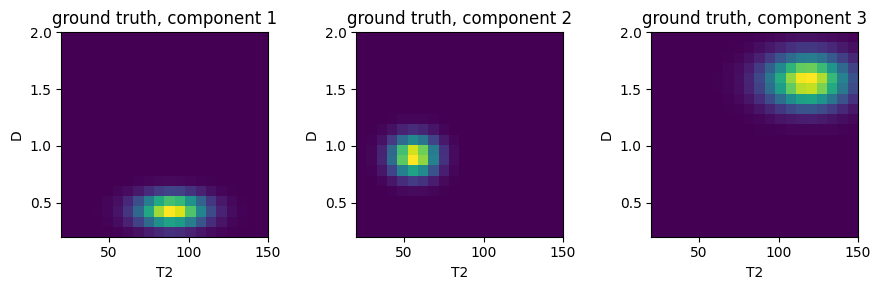

In [3]:

Dmin, T2min, Dmax, T2max, nD, nT2 = 0.2, 20.0, 2.0, 150.0, 20, 20
Bmin, Bmax, nB, TEmin, TEmax, nTE = 0.0, 4.0, 8, 20.0, 180.0, 8

voxels_to_show = [10, 20, 30, 40, 50, 60, 70]

# three ground-truth compartments, each a Gaussian blob in (D, T2) space
D_means = [0.4, 0.9, 1.6]
D_stds = [0.10, 0.12, 0.16]
T2_means = [90, 55, 120]
T2_stds = [15, 10, 18]

D_grid, T2_grid = create_DT2_grid(Dmin, Dmax, nD, T2min, T2max, nT2)
D_vals = np.linspace(Dmin, Dmax, nD)
T2_vals = np.linspace(T2min, T2max, nT2)
b_vals = np.linspace(Bmin, Bmax, nB)
TE_vals = np.linspace(TEmin, TEmax, nTE)

# Define fitting parameters
K=3; # Number of canonical spectra
V=80; # Number of voxels
R=10   # Rank for SVD    

D,T2=create_DT2_grid(Dmin,Dmax,nD,T2min,T2max,nT2); 
# Create A matrix
A = create_A_matrix(D,T2,Bmin,Bmax,nB,TEmin,TEmax,nTE); 
# Create true C - canonical spectra
# Here have hardcoded centres
C_true = create_gaussian_compartments(D_grid, T2_grid, D_means, D_stds, T2_means, T2_stds)

# Define GT weights
W_true = rng.uniform(size=(K, V))
W_true /= W_true.sum(axis=0, keepdims=True)

# Set scale parameter
M0_true=np.ones(V)*300;

# Calulate the signal Y = M0 * A * C_true * W_true
SNR = 50
sigma = M0_true/SNR # sigma needs to scale with M0
Y=create_signal(A,C_true,W_true,M0_true,sigma,rng)

# Create GT C_small using SVD
U,s,Vmat=apply_SVD_to_A(A,R)
C_small_true=project_C_to_C_small(C_true,s,Vmat)
#C_small_true = np.diag(s) @ V_mat.T @ C_true - should be equivalent

show_canonical_spectra([('ground truth', C_true)])


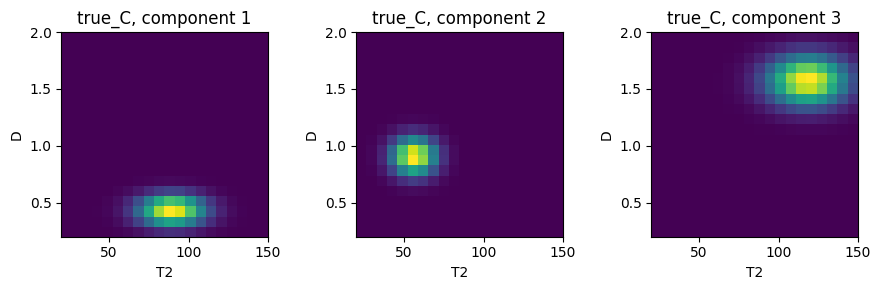

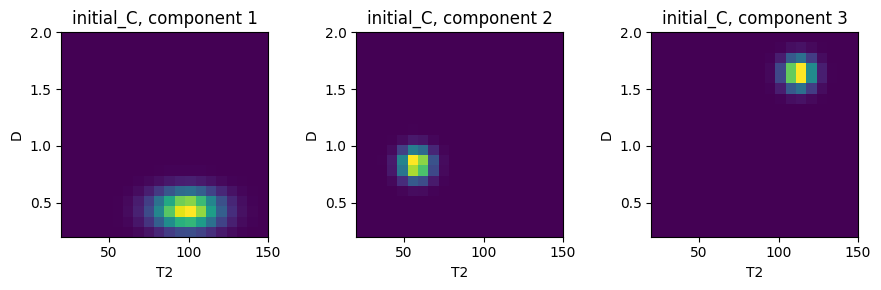

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Initial M0: [299.36084844 296.38478696 289.08154688 298.31757471 310.09086569
 287.08208365 302.01815591 279.60670198 289.96830436 298.9505419
 295.15375559 292.26480477 288.72873282 276.27978363 293.31081569
 283.53481893 302.69638597 299.42786521 282.86925121 288.11977656
 286.5513976  294.46819507 291.86313009 289.62172371 282.70949432
 280.41586565 281.34978699 279.12280384 283.34490159 292.44664591
 294.87348914 291.12454228 273.61687458 297.17317802 289.81176851
 295.84248586 285.79353771 300.8203187  275.75519581 268.36366168
 292.37031127 300.79184293 291.25627022 295.5

In [4]:
# Set intial conditions
C0=define_initial_C_NNLS_mean(Y,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
#^^^ This function could be re-written to not have so many arguments 
Csmall0=project_C_to_C_small(C0,s,Vmat); 

M0_init = initialize_M0_monoexponential(Y, b_vals, TE_vals)

W0 = initialize_W_from_C(Y, U, Csmall0, M0_init, bound_eps=1e-3)

C0,W0=order_components(C_true, C0, W0, K)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
print("True M0:", M0_true)
print("Initial M0:", M0_init)


### Poster figures


iter 0: loss=2405.6456, fit_err=177196.447350, sigma2=36.000000
iter 100: loss=2391.1042, fit_err=176150.427881, sigma2=36.000000
iter 200: loss=2391.1042, fit_err=176150.427854, sigma2=36.000000
W MAE: 0.036708701544122195
M0 MAE: 10.776460964220798
C MAE: 0.0046240875210688944


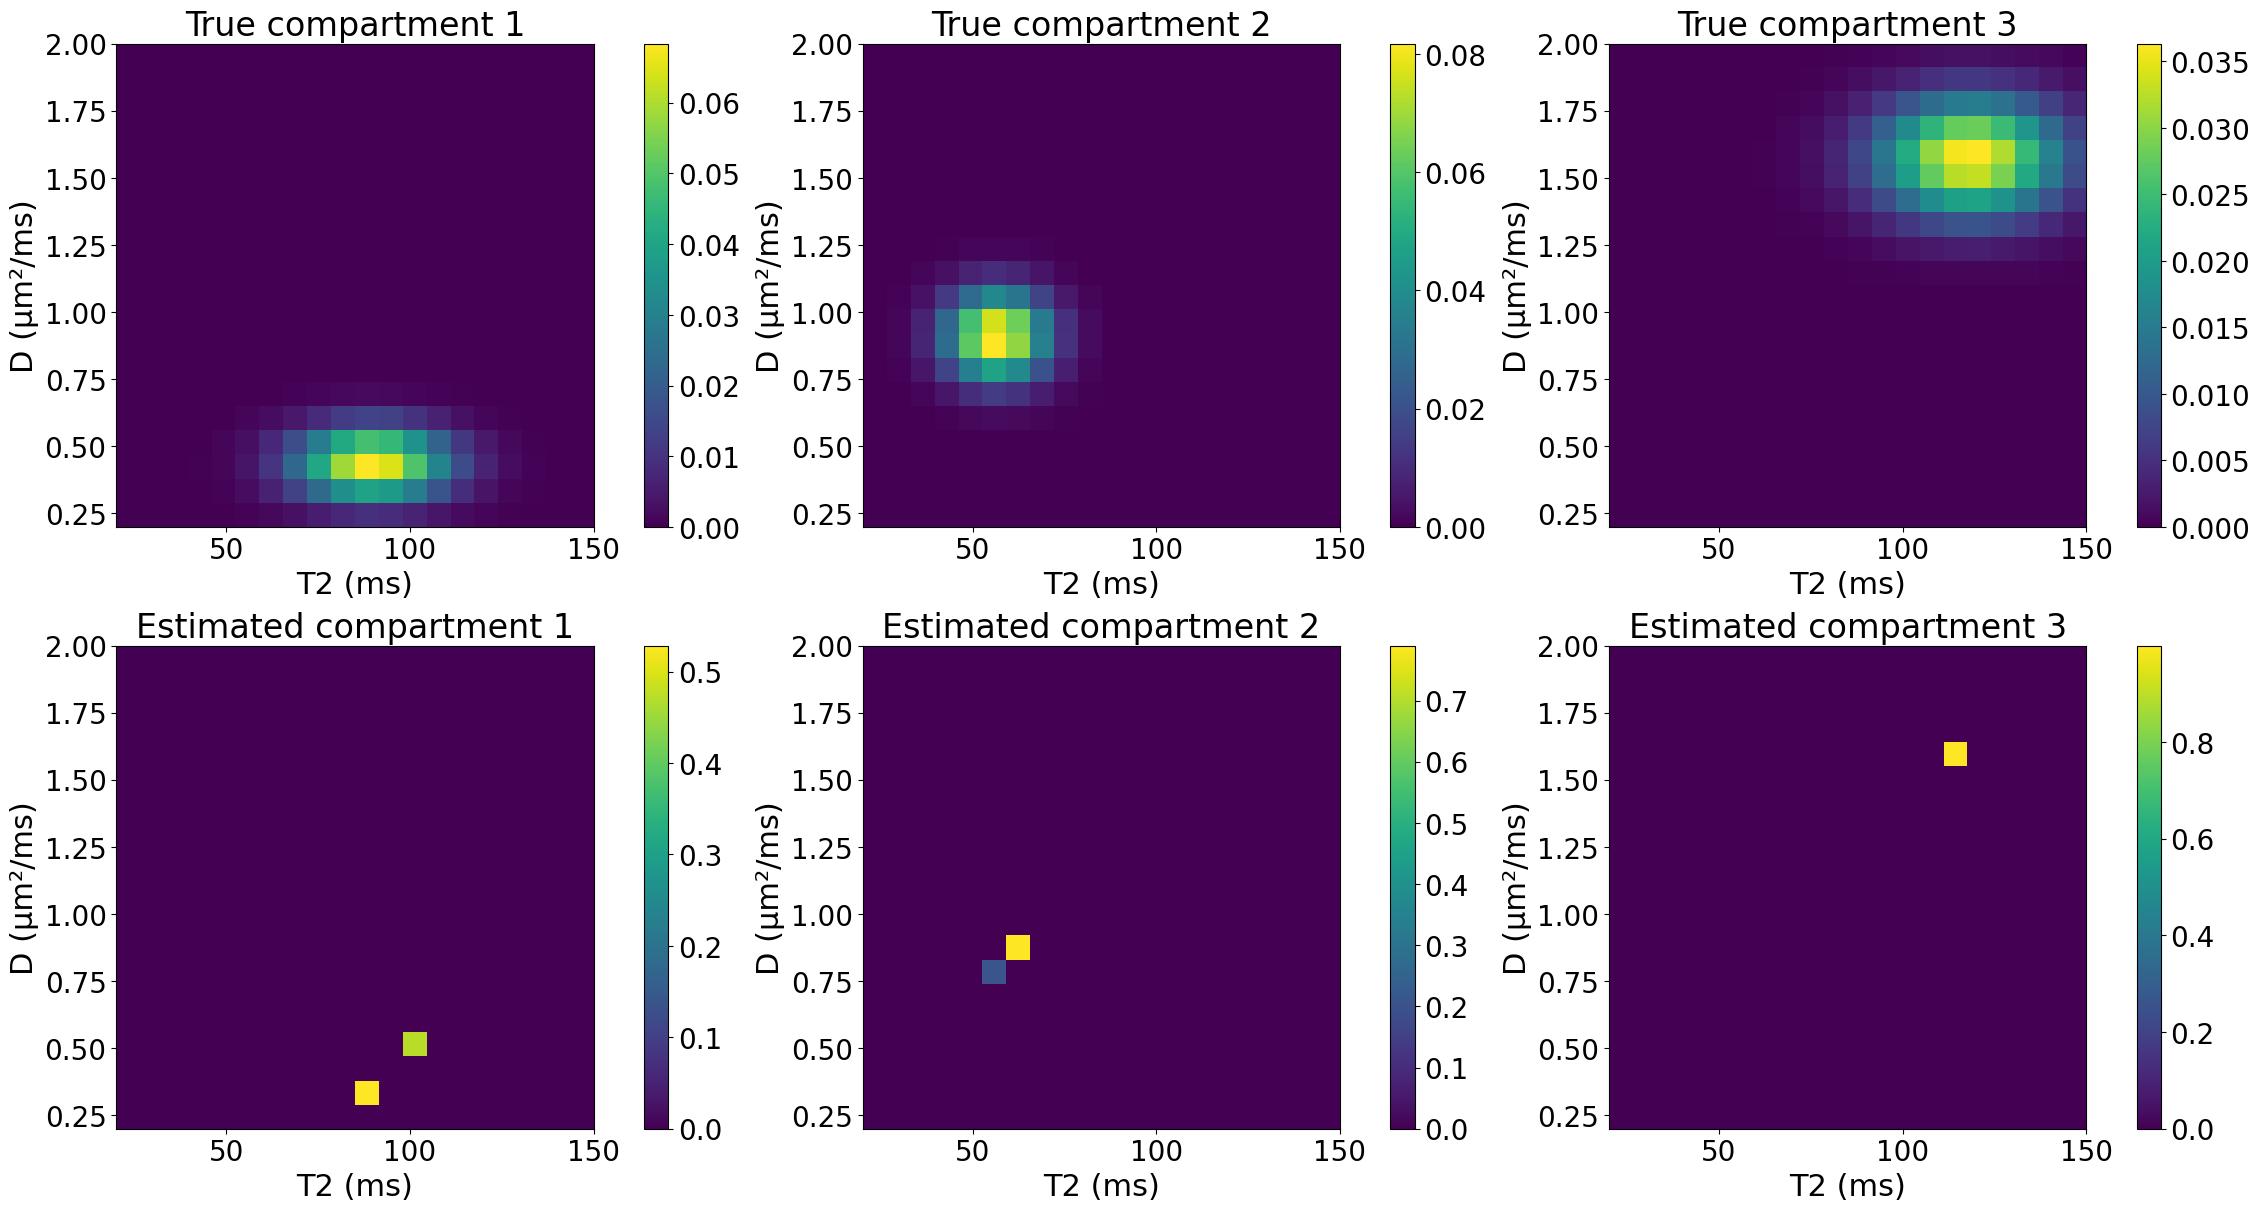

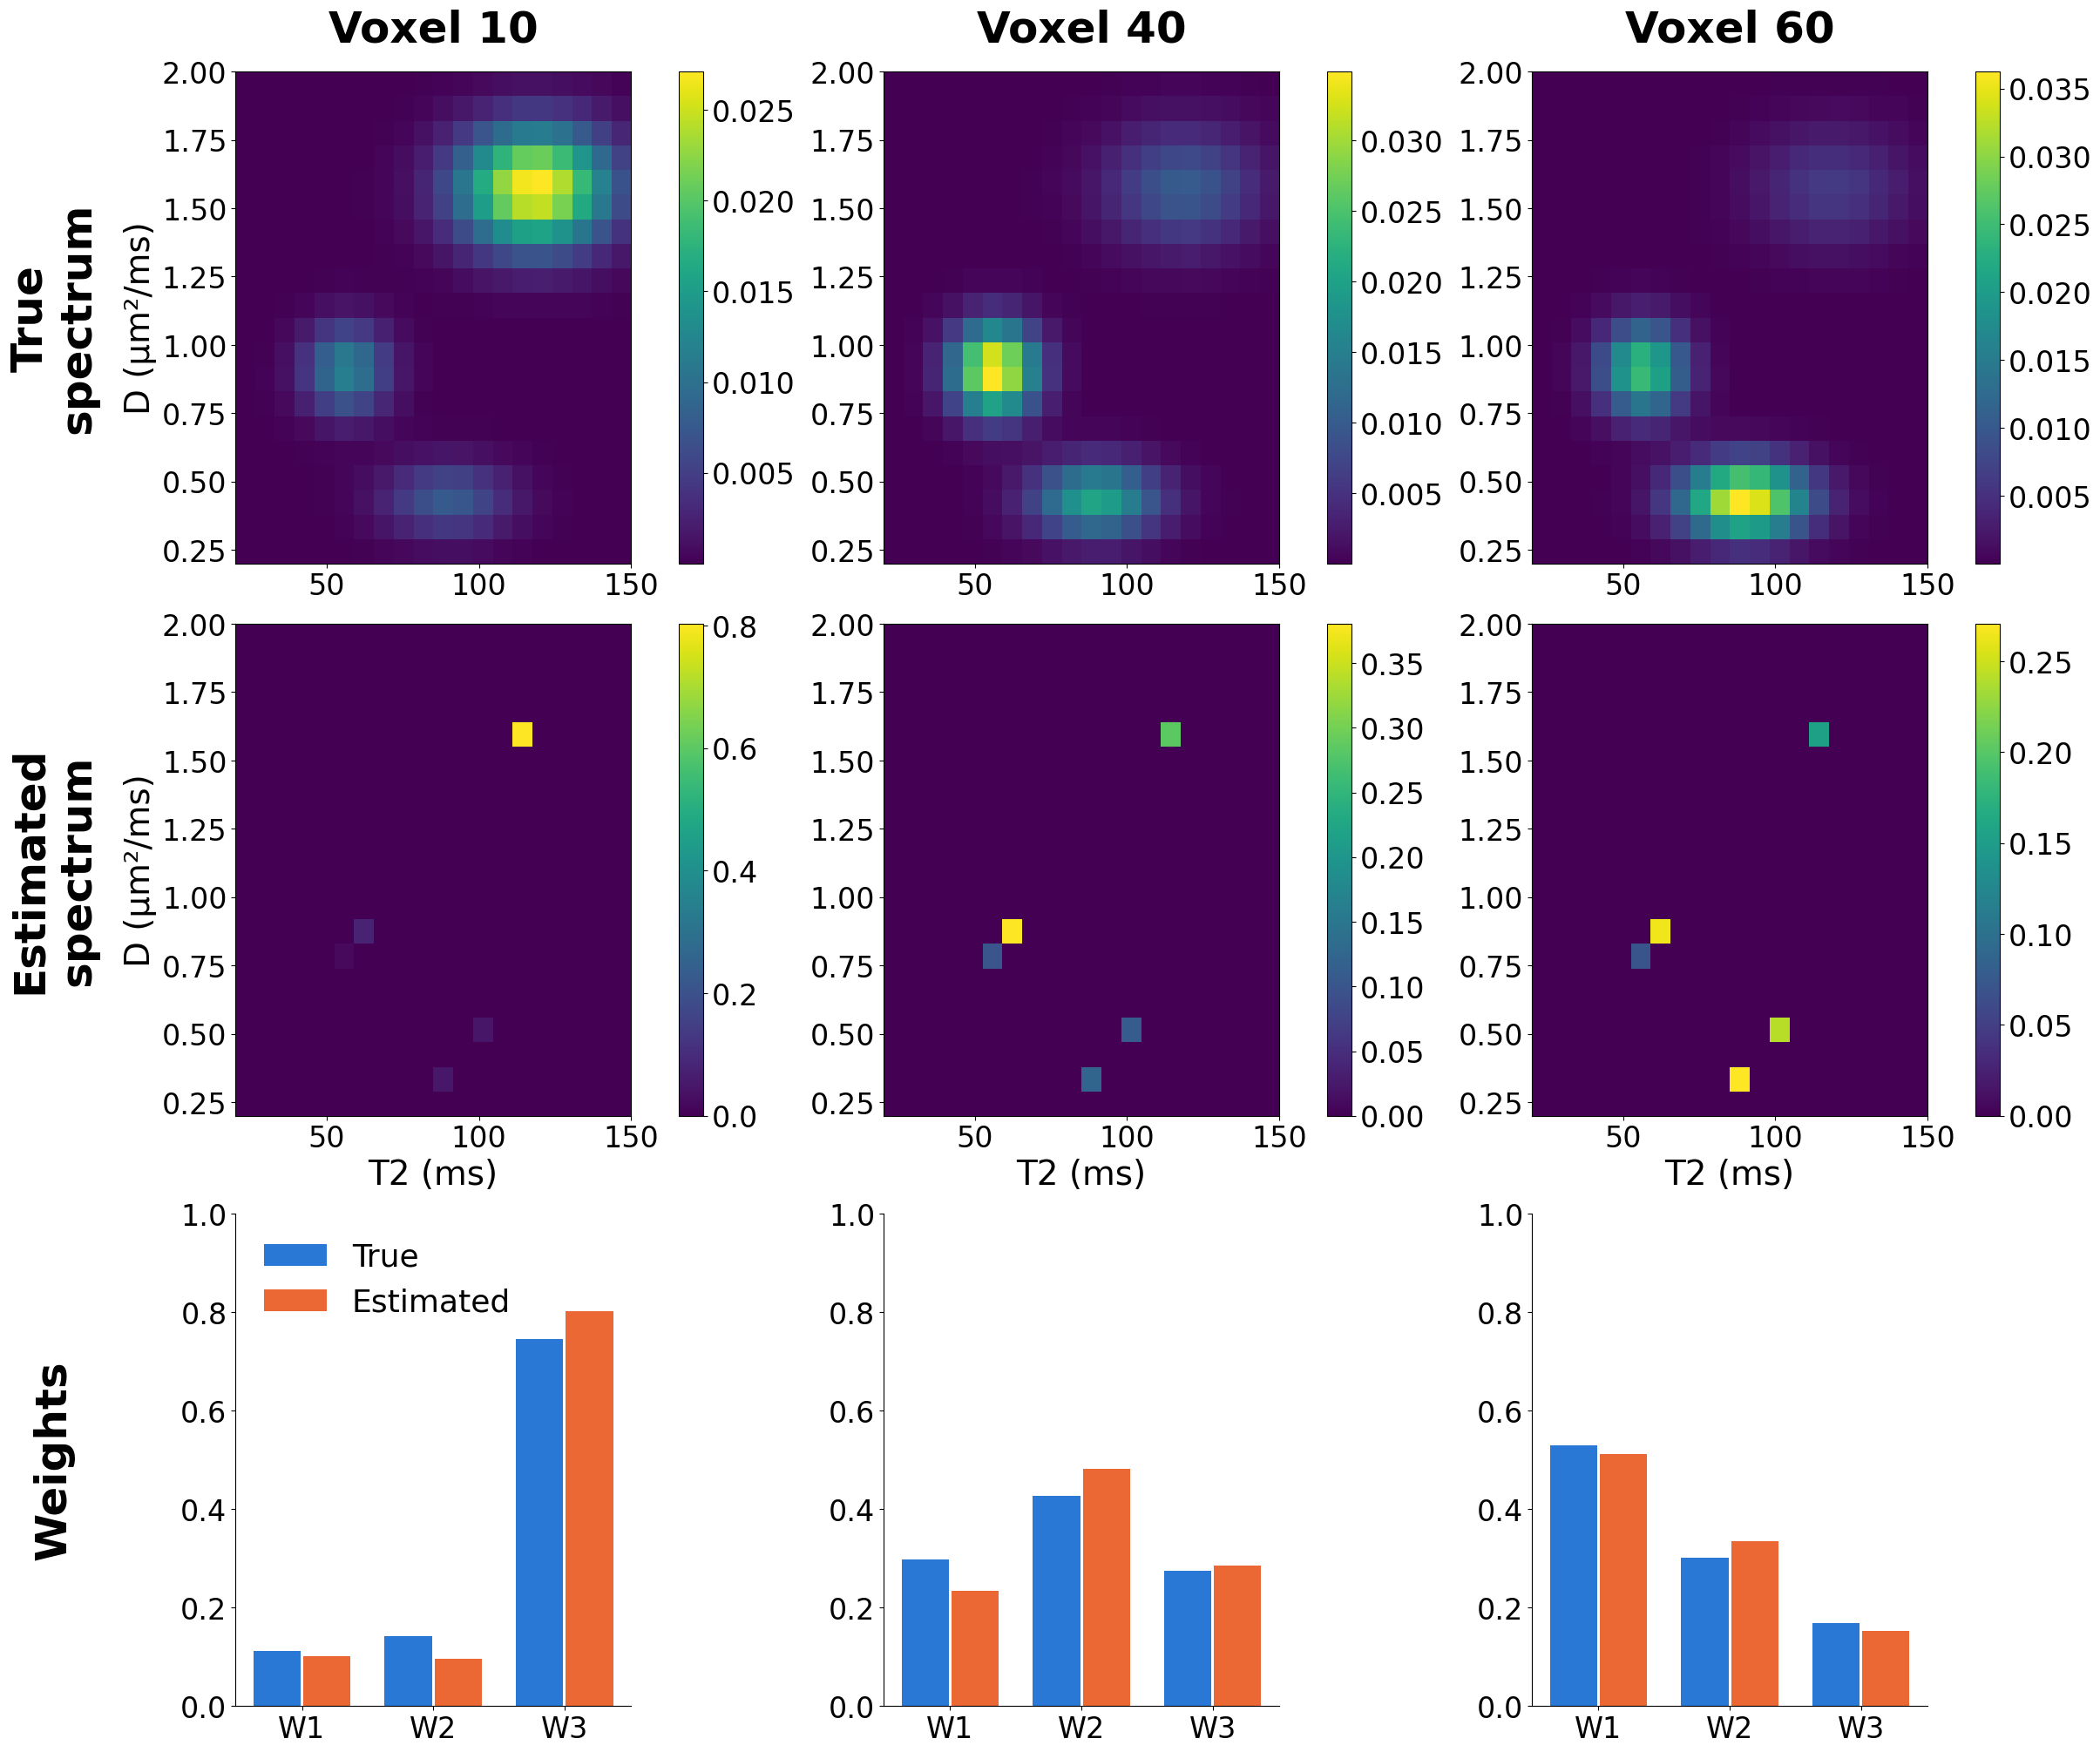

In [5]:
# Poster figures: constrained optimisation on the initial simulated dataset
# (Y, W_true, C0, W0, M0_init from the cells at the top of the notebook)

poster_voxels = [10, 40, 60]
fs = 22   # base font size

W_est_p, M0_est_p, C_est_p, alpha_est_p, sigma2_est_p, lam_est_p, losses_p, fit_errs_p = (
    run_constrained_optimisation(
        Y, U, s, Vmat,
        C0, M0_init,
        K=K,
        n_iter=300,
        sigma2=np.mean(sigma**2),      # choose from expected noise level
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,
        m0_prior_sigma=0.15,

        alpha=1.0,                  # disables Dirichlet prior
        update_alpha_flag=False,
        alpha_update_start=5,      # allow C/W to settle first
        weight_entropy=0.0,        # do not combine with entropy here

        c_sparsity=0.0,            # make C sparse
        c_smoothness=0.0,          # make C smooth
        c_diversity=0.0,           # encourage diversity in C (is components not the same)
        c_maxiter=100,
        nD=nD,
        nT2=nT2,

        verbose_every=100,
    )
)

C_est_p, W_est_p = order_components(C_true, C_est_p, W_est_p, K)

print("W MAE:", np.mean(np.abs(W_true - W_est_p)))
print("M0 MAE:", np.mean(np.abs(M0_true - M0_est_p)))
print("C MAE:", np.mean(np.abs(C_true - C_est_p)))

F_true_p = C_true @ W_true
F_est_p = C_est_p @ W_est_p

extent = [T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()]
poster_fonts = {"font.size": fs, "axes.titlesize": fs + 2, "axes.labelsize": fs,
                "xtick.labelsize": fs - 2, "ytick.labelsize": fs - 2, "legend.fontsize": fs - 2}

# Figure 1: true and estimated compartments
with plt.rc_context(poster_fonts):
    fig, axes = plt.subplots(2, K, figsize=(7.5 * K, 12), constrained_layout=True)

    for row, (name, C) in enumerate([("True", C_true), ("Estimated", C_est_p)]):
        for k in range(K):
            image = axes[row, k].imshow(C[:, k].reshape(nD, nT2), origin="lower", aspect="auto", extent=extent)
            axes[row, k].set_title(f"{name} compartment {k + 1}")
            axes[row, k].set_xlabel("T2 (ms)")
            axes[row, k].set_ylabel("D (µm²/ms)")
            fig.colorbar(image, ax=axes[row, k])

    fig.savefig("poster_simulation_compartments.png", dpi=300, bbox_inches="tight")
    plt.show()
# Figure 2: true and estimated spectra and weights for a few voxels
fs2 = 28   # font size for this figure
row_names = ["True\nspectrum", "Estimated\nspectrum", "Weights"]

with plt.rc_context({"font.size": fs2, "axes.labelsize": fs2, "xtick.labelsize": fs2 - 4,
                     "ytick.labelsize": fs2 - 4, "legend.fontsize": fs2 - 2}):
    fig, axes = plt.subplots(3, len(poster_voxels), figsize=(8 * len(poster_voxels), 20), constrained_layout=True)

    components = np.arange(K)
    for col, voxel in enumerate(poster_voxels):
        # Column header
        axes[0, col].set_title(f"Voxel {voxel}", fontsize=fs2 + 8, fontweight="bold", pad=25)

        for row, F in enumerate([F_true_p, F_est_p]):
            image = axes[row, col].imshow(F[:, voxel].reshape(nD, nT2), origin="lower", aspect="auto", extent=extent)
            fig.colorbar(image, ax=axes[row, col])
            if col == 0:
                axes[row, col].set_ylabel("D (µm²/ms)")
        axes[1, col].set_xlabel("T2 (ms)")

        axes[2, col].bar(components - 0.19, W_true[:, voxel], 0.36, color="#2a78d6", label="True")
        axes[2, col].bar(components + 0.19, W_est_p[:, voxel], 0.36, color="#eb6834", label="Estimated")
        axes[2, col].set(xticks=components, xticklabels=[f"W{k + 1}" for k in components], ylim=(0, 1))
        axes[2, col].spines[["top", "right"]].set_visible(False)
    axes[2, 0].legend(frameon=False)

    # Row headers
    for row, name in enumerate(row_names):
        axes[row, 0].annotate(name, xy=(0, 0.5), xycoords="axes fraction", xytext=(-150, 0),
                              textcoords="offset points", ha="center", va="center", rotation=90,
                              fontsize=fs2 + 8, fontweight="bold")

    fig.savefig("poster_simulation_voxels.png", dpi=300, bbox_inches="tight")
    plt.show()


### Numbers for the poster


In [6]:
# Numbers to quote next to the poster figure
W_err = np.abs(W_true - W_est_p)
M0_rel = np.abs(M0_est_p - M0_true) / M0_true
Y_fit = (A @ C_est_p @ W_est_p) * M0_est_p

print(f"Setup: {V} voxels, {A.shape[0]} measurements per voxel, SNR {SNR}, {K} compartments")
print(f"Weights: mean abs error {W_err.mean():.3f}, max {W_err.max():.3f}, correlation r = {np.corrcoef(W_true.ravel(), W_est_p.ravel())[0, 1]:.3f}")
print(f"M0: mean relative error {100 * M0_rel.mean():.1f}%")
print(f"Signal: relative residual {100 * np.linalg.norm(Y - Y_fit) / np.linalg.norm(Y):.1f}%")

# Peak position of each compartment, true vs estimated
for k in range(K):
    iD_t, iT_t = np.unravel_index(np.argmax(C_true[:, k]), (nD, nT2))
    iD_e, iT_e = np.unravel_index(np.argmax(C_est_p[:, k]), (nD, nT2))
    print(f"Compartment {k + 1} peak: true (D = {D_vals[iD_t]:.2f}, T2 = {T2_vals[iT_t]:.0f} ms), "
          f"estimated (D = {D_vals[iD_e]:.2f}, T2 = {T2_vals[iT_e]:.0f} ms)")


Setup: 80 voxels, 64 measurements per voxel, SNR 50, 3 compartments
Weights: mean abs error 0.037, max 0.171, correlation r = 0.967
M0: mean relative error 3.6%
Signal: relative residual 10.2%
Compartment 1 peak: true (D = 0.39, T2 = 88 ms), estimated (D = 0.29, T2 = 88 ms)
Compartment 2 peak: true (D = 0.86, T2 = 54 ms), estimated (D = 0.86, T2 = 61 ms)
Compartment 3 peak: true (D = 1.62, T2 = 123 ms), estimated (D = 1.62, T2 = 116 ms)
